# Electronics Sales Analysis Using Python


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
project_data = pd.read_excel("Project Data.xlsx")

In [3]:
project_data.drop("sales",axis=1,inplace=True)

In [4]:
project_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",NaN
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",NaN
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",NaN
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",NaN
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",NaN
...,...,...,...,...,...,...,...
186845,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",NaN
186846,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",NaN
186847,319668,Vareebadd Phone,1,400,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",NaN
186848,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",NaN


### DataFrame Overview


In [5]:
project_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order ID          185973 non-null  object 
 1   Product           186305 non-null  object 
 2   Quantity Ordered  185973 non-null  object 
 3   Price Each        185973 non-null  object 
 4   Order Date        185973 non-null  object 
 5   Purchase Address  186305 non-null  object 
 6   Month             0 non-null       float64
dtypes: float64(1), object(6)
memory usage: 10.0+ MB


### Data Cleaning and Data Type Preparation

- Identify and remove empty records.
- Convert columns to the appropriate data types.


### Checking for Missing Values


In [7]:
project_data.isna().sum()

Order ID               877
Product                545
Quantity Ordered       877
Price Each             877
Order Date             877
Purchase Address       545
Month               186850
dtype: int64

### Filtering Records with Missing Order IDs


In [9]:
project_data[project_data["Order ID"].isna()]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
797,NaN,NaN,NaN,NaN,NaN,NaN,NaN
876,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1073,NaN,Product,NaN,NaN,NaN,Purchase Address,NaN
...,...,...,...,...,...,...,...
185481,NaN,Product,NaN,NaN,NaN,Purchase Address,NaN
185729,NaN,NaN,NaN,NaN,NaN,NaN,NaN
185925,NaN,Product,NaN,NaN,NaN,Purchase Address,NaN
185955,NaN,Product,NaN,NaN,NaN,Purchase Address,NaN


### Filtering Non-Missing Records


In [10]:
(~project_data["Order ID"].isna())

0         True
1         True
2         True
3         True
4         True
          ... 
186845    True
186846    True
186847    True
186848    True
186849    True
Name: Order ID, Length: 186850, dtype: bool

In [11]:
project_data[(~project_data["Order ID"].isna())]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",NaN
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",NaN
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",NaN
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",NaN
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",NaN
...,...,...,...,...,...,...,...
186845,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",NaN
186846,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",NaN
186847,319668,Vareebadd Phone,1,400,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",NaN
186848,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",NaN


In [12]:
project_data = project_data[(~project_data["Order ID"].isna())]

In [13]:
project_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",NaN
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",NaN
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",NaN
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",NaN
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",NaN
...,...,...,...,...,...,...,...
186845,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",NaN
186846,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",NaN
186847,319668,Vareebadd Phone,1,400,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",NaN
186848,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",NaN


### Converting Columns to the Appropriate Data Types

- Convert numeric columns using `pd.to_numeric()`.
- Convert date columns using `pd.to_datetime()`.


In [12]:
pd.to_numeric(project_data["Quantity Ordered"])

ValueError: Unable to parse string "Quantity Ordered" at position 71822

In [13]:
project_data.iloc[71822]

Order ID                    Order ID
Product                      Product
Quantity Ordered    Quantity Ordered
Price Each                Price Each
Order Date                Order Date
Purchase Address    Purchase Address
Month                            NaN
Name: 72161, dtype: object

In [14]:
project_data[project_data["Quantity Ordered"] == "Quantity Ordered"]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
72161,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,NaN
72993,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,NaN
73682,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,NaN
73687,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,NaN
75129,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,NaN
75215,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,NaN
75921,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,NaN
76200,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,NaN
76232,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,NaN
76332,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,NaN


In [20]:
project_data[~(project_data["Quantity Ordered"] == "Quantity Ordered")]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",NaN
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",NaN
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",NaN
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",NaN
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",NaN
...,...,...,...,...,...,...,...
186845,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",NaN
186846,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",NaN
186847,319668,Vareebadd Phone,1,400,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",NaN
186848,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",NaN


In [21]:
project_data = project_data[~(project_data["Quantity Ordered"] == "Quantity Ordered")]

In [22]:
project_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",NaN
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",NaN
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",NaN
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",NaN
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",NaN
...,...,...,...,...,...,...,...
186845,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",NaN
186846,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",NaN
186847,319668,Vareebadd Phone,1,400,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",NaN
186848,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",NaN


In [23]:
pd.to_numeric(project_data["Quantity Ordered"])

0         1
1         1
2         2
3         1
4         1
         ..
186845    1
186846    2
186847    1
186848    1
186849    1
Name: Quantity Ordered, Length: 185950, dtype: int64

In [24]:
project_data["Quantity Ordered"]=pd.to_numeric(project_data["Quantity Ordered"])

In [25]:
pd.to_numeric(project_data["Price Each"])

0         700.00
1          14.95
2          11.99
3         149.99
4          11.99
           ...  
186845     14.95
186846      3.84
186847    400.00
186848     11.99
186849     99.99
Name: Price Each, Length: 185950, dtype: float64

In [28]:
project_data["Price Each"]=pd.to_numeric(project_data["Price Each"])

In [30]:
pd.to_datetime(project_data["Order Date"])

0        2019-01-22 21:25:00
1        2019-01-28 14:15:00
2        2019-01-17 13:33:00
3        2019-01-05 20:33:00
4        2019-01-25 11:59:00
                 ...        
186845   2019-12-11 20:58:00
186846   2019-12-01 12:01:00
186847   2019-12-09 06:43:00
186848   2019-12-03 10:39:00
186849   2019-12-21 21:45:00
Name: Order Date, Length: 185950, dtype: datetime64[ns]

In [32]:
project_data["Order Date"]=pd.to_datetime(project_data["Order Date"])

In [33]:
project_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",NaN
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",NaN
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",NaN
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",NaN
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",NaN
...,...,...,...,...,...,...,...
186845,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",NaN
186846,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",NaN
186847,319668,Vareebadd Phone,1,400.00,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",NaN
186848,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",NaN


In [34]:
project_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185950 entries, 0 to 186849
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185950 non-null  object        
 1   Product           185950 non-null  object        
 2   Quantity Ordered  185950 non-null  int64         
 3   Price Each        185950 non-null  float64       
 4   Order Date        185950 non-null  datetime64[ns]
 5   Purchase Address  185950 non-null  object        
 6   Month             0 non-null       float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 11.3+ MB


In [35]:
project_data.isna().sum()

Order ID                 0
Product                  0
Quantity Ordered         0
Price Each               0
Order Date               0
Purchase Address         0
Month               185950
dtype: int64

In [36]:
project_data["Sales"] = project_data["Quantity Ordered"]*project_data["Price Each"]

### Extracting Date Components


In [38]:
project_data["Order Date"].dt.year

0         2019
1         2019
2         2019
3         2019
4         2019
          ... 
186845    2019
186846    2019
186847    2019
186848    2019
186849    2019
Name: Order Date, Length: 185950, dtype: int32

In [39]:
project_data["Month"] = project_data["Order Date"].dt.month

In [40]:
project_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
0,141234,iPhone,1,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",1,700.00
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",1,14.95
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",1,23.98
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",1,149.99
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",1,11.99
...,...,...,...,...,...,...,...,...
186845,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",12,14.95
186846,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",12,7.68
186847,319668,Vareebadd Phone,1,400.00,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",12,400.00
186848,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",12,11.99


In [41]:
project_data.groupby("Month")["Sales"].sum()

Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Sales, dtype: float64

In [42]:
project_data.groupby("Month")["Sales"].sum().sort_values(ascending=False)

Month
12    4613443.34
10    3736726.88
4     3390670.24
11    3199603.20
5     3152606.75
3     2807100.38
7     2647775.76
6     2577802.26
8     2244467.88
2     2202022.42
9     2097560.13
1     1822256.73
Name: Sales, dtype: float64

In [43]:
monthly_sales  = project_data.groupby("Month")["Sales"].sum()
monthly_sales 


Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Sales, dtype: float64

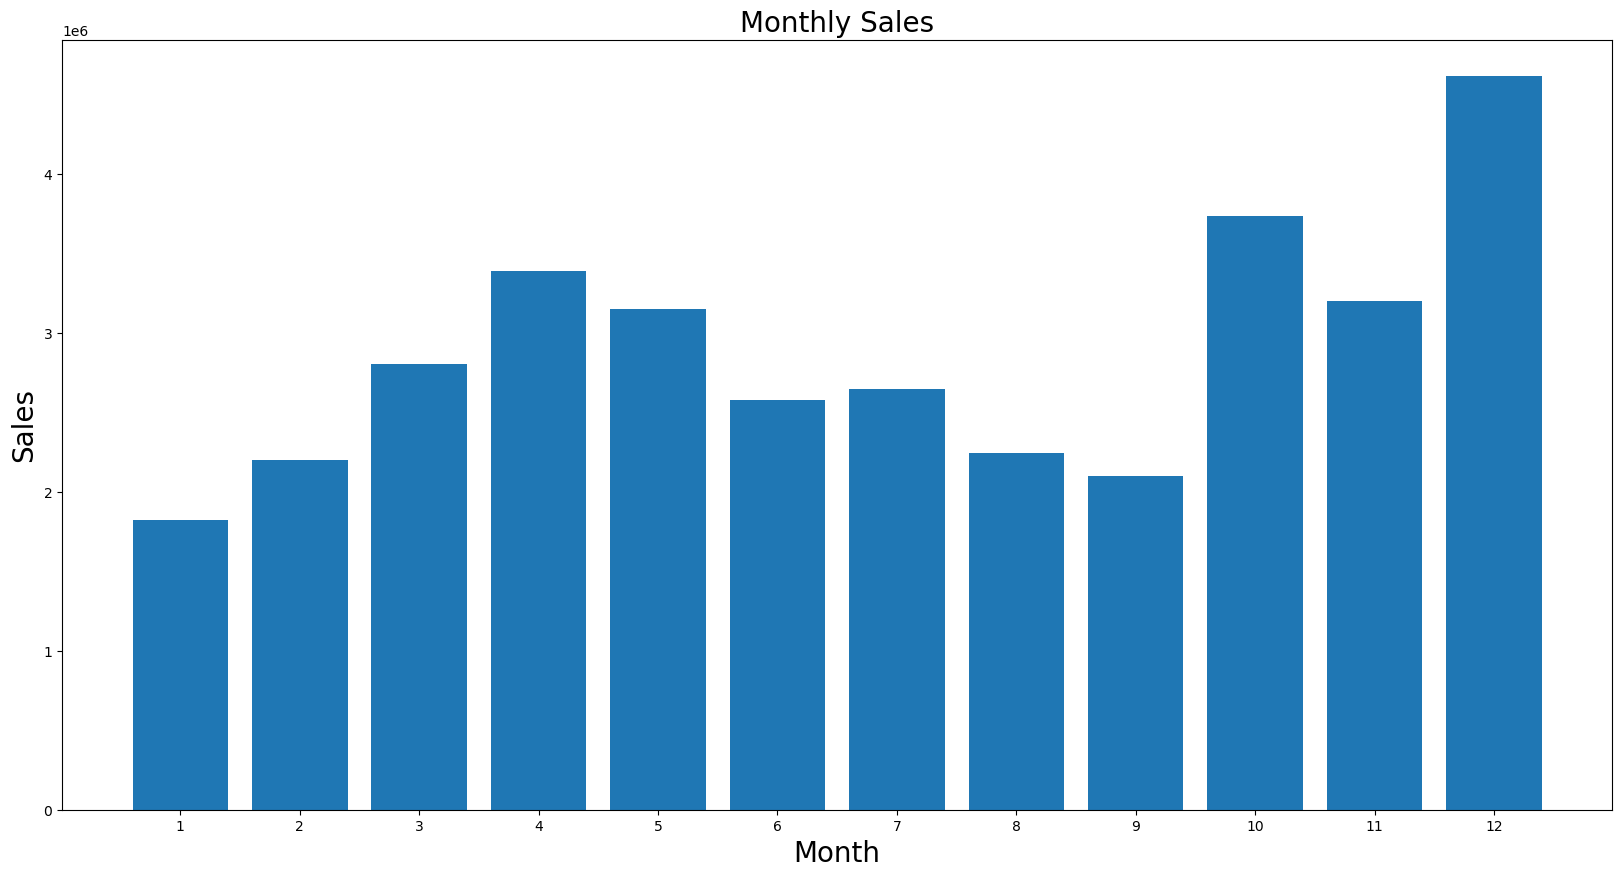

In [50]:
plt.figure(figsize=(20,10))
plt.bar(monthly_sales.index,monthly_sales.values)
plt.xticks(monthly_sales.index)
plt.xlabel("Month",fontdict={"fontsize":20,"fontweight":10})
plt.ylabel("Sales",fontdict={"fontsize":20,"fontweight":10})
plt.title("Monthly Sales",fontdict={"fontsize":20,"fontweight":10})
plt.show()

In [51]:
project_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
0,141234,iPhone,1,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",1,700.00
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",1,14.95
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",1,23.98
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",1,149.99
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",1,11.99


In [52]:
project_data["Purchase Address"].str.split(",",expand=True)[1]

0                 Boston
1               Portland
2          San Francisco
3            Los Angeles
4                 Austin
               ...      
186845     San Francisco
186846       Los Angeles
186847           Seattle
186848            Dallas
186849       Los Angeles
Name: 1, Length: 185950, dtype: object

In [54]:
project_data["Purchase Address"].str.split(",",expand=True)

,0,1,2
0,944 Walnut St,Boston,MA 02215
1,185 Maple St,Portland,OR 97035
2,538 Adams St,San Francisco,CA 94016
3,738 10th St,Los Angeles,CA 90001
4,387 10th St,Austin,TX 73301
...,...,...,...
186845,14 Madison St,San Francisco,CA 94016
186846,549 Willow St,Los Angeles,CA 90001
186847,273 Wilson St,Seattle,WA 98101
186848,778 River St,Dallas,TX 75001


In [56]:
cities = project_data["Purchase Address"].str.split(",",expand=True)[1]
cities

0                 Boston
1               Portland
2          San Francisco
3            Los Angeles
4                 Austin
               ...      
186845     San Francisco
186846       Los Angeles
186847           Seattle
186848            Dallas
186849       Los Angeles
Name: 1, Length: 185950, dtype: object

In [57]:
project_data["Purchase Address"].str.split(",",expand=True)[2]

0          MA 02215
1          OR 97035
2          CA 94016
3          CA 90001
4          TX 73301
            ...    
186845     CA 94016
186846     CA 90001
186847     WA 98101
186848     TX 75001
186849     CA 90001
Name: 2, Length: 185950, dtype: object

In [58]:
states = project_data["Purchase Address"].str.split(",",expand=True)[2].str.split(expand=True)[0]
states

0         MA
1         OR
2         CA
3         CA
4         TX
          ..
186845    CA
186846    CA
186847    WA
186848    TX
186849    CA
Name: 0, Length: 185950, dtype: object

In [59]:
cities + "("+states+")"

0                 Boston(MA)
1               Portland(OR)
2          San Francisco(CA)
3            Los Angeles(CA)
4                 Austin(TX)
                 ...        
186845     San Francisco(CA)
186846       Los Angeles(CA)
186847           Seattle(WA)
186848            Dallas(TX)
186849       Los Angeles(CA)
Length: 185950, dtype: object

In [60]:
project_data["Cities"] = cities + "("+states+")"

In [61]:
project_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,Cities
0,141234,iPhone,1,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",1,700.00,Boston(MA)
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",1,14.95,Portland(OR)
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",1,23.98,San Francisco(CA)
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",1,149.99,Los Angeles(CA)
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",1,11.99,Austin(TX)
...,...,...,...,...,...,...,...,...,...
186845,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",12,14.95,San Francisco(CA)
186846,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",12,7.68,Los Angeles(CA)
186847,319668,Vareebadd Phone,1,400.00,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",12,400.00,Seattle(WA)
186848,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",12,11.99,Dallas(TX)


In [62]:
project_data.groupby("Cities")["Sales"].sum()

Cities
Atlanta(GA)          2795498.58
Austin(TX)           1819581.75
Boston(MA)           3661642.01
Dallas(TX)           2767975.40
Los Angeles(CA)      5452570.80
New York City(NY)    4664317.43
Portland(ME)          449758.27
Portland(OR)         1870732.34
San Francisco(CA)    8262203.91
Seattle(WA)          2747755.48
Name: Sales, dtype: float64

In [63]:
cities_sales = project_data.groupby("Cities")["Sales"].sum()
cities_sales

Cities
Atlanta(GA)          2795498.58
Austin(TX)           1819581.75
Boston(MA)           3661642.01
Dallas(TX)           2767975.40
Los Angeles(CA)      5452570.80
New York City(NY)    4664317.43
Portland(ME)          449758.27
Portland(OR)         1870732.34
San Francisco(CA)    8262203.91
Seattle(WA)          2747755.48
Name: Sales, dtype: float64

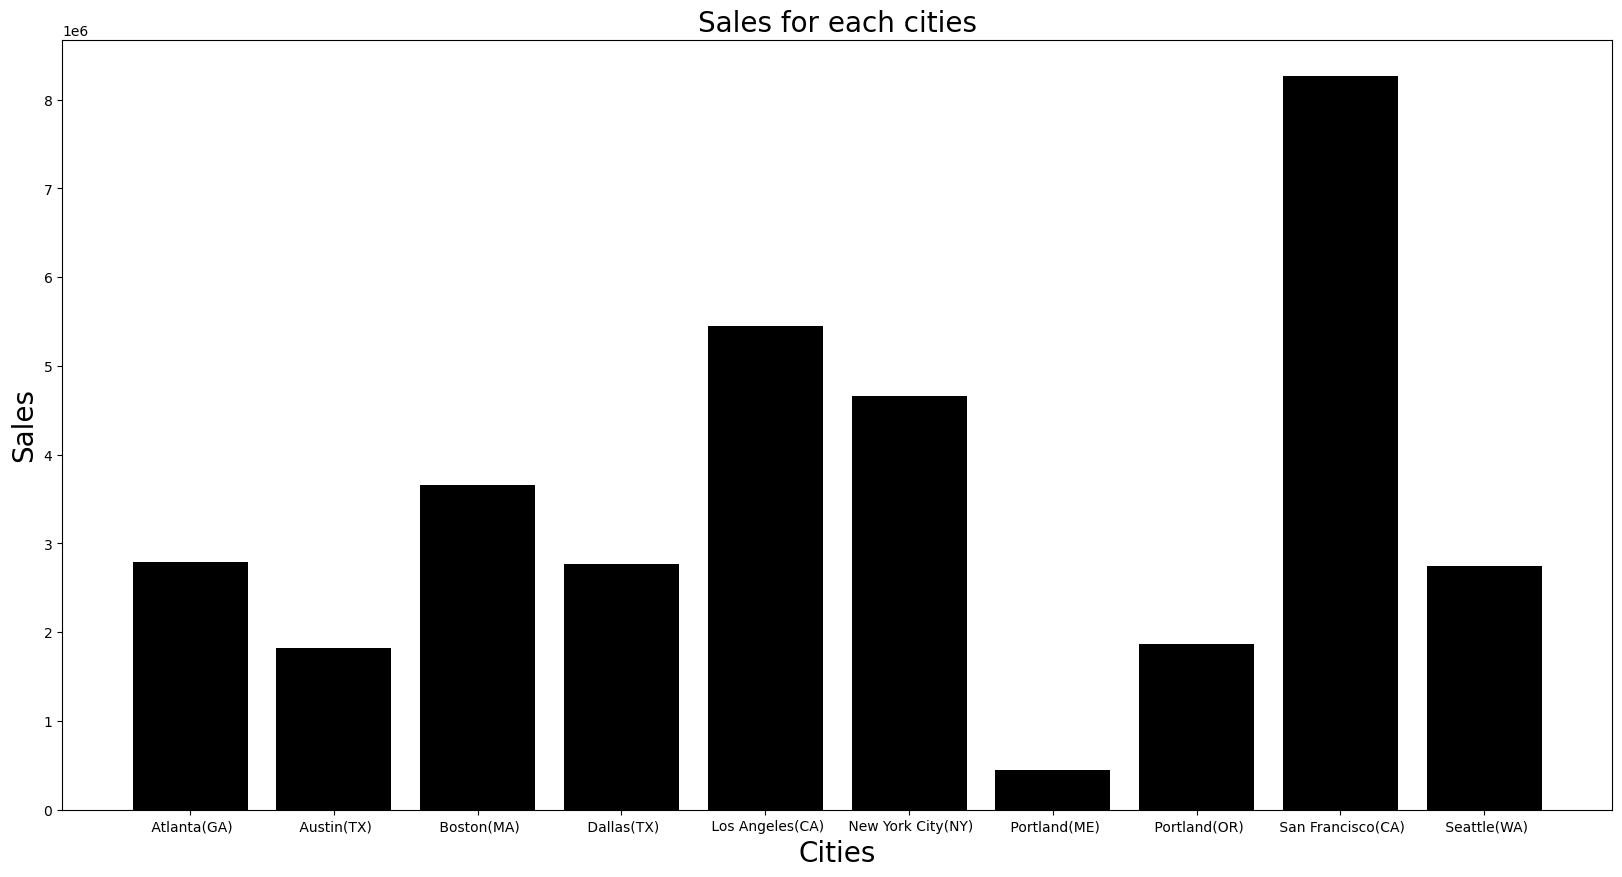

In [70]:
plt.figure(figsize=(20,10))
plt.bar(cities_sales.index,cities_sales.values,color="k")
plt.xlabel("Cities",fontdict={"fontsize":20,"fontweight":10})
plt.ylabel("Sales",fontdict={"fontsize":20,"fontweight":10})
plt.title("Sales for each cities",fontdict={"fontsize":20,"fontweight":10})
plt.show()

In [71]:
project_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,Cities
0,141234,iPhone,1,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",1,700.00,Boston(MA)
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",1,14.95,Portland(OR)
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",1,23.98,San Francisco(CA)
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",1,149.99,Los Angeles(CA)
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",1,11.99,Austin(TX)


In [72]:
project_data["Order Date"].dt.hour

0         21
1         14
2         13
3         20
4         11
          ..
186845    20
186846    12
186847     6
186848    10
186849    21
Name: Order Date, Length: 185950, dtype: int32

In [74]:
project_data["Hour"]=project_data["Order Date"].dt.hour

In [75]:
project_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,Cities,Hour
0,141234,iPhone,1,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",1,700.00,Boston(MA),21
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",1,14.95,Portland(OR),14
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",1,23.98,San Francisco(CA),13
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",1,149.99,Los Angeles(CA),20
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",1,11.99,Austin(TX),11


In [77]:
order_hour = project_data.groupby("Hour")["Sales"].count()

In [ ]:
#order_hour =project_data["Hour"].value_counts()

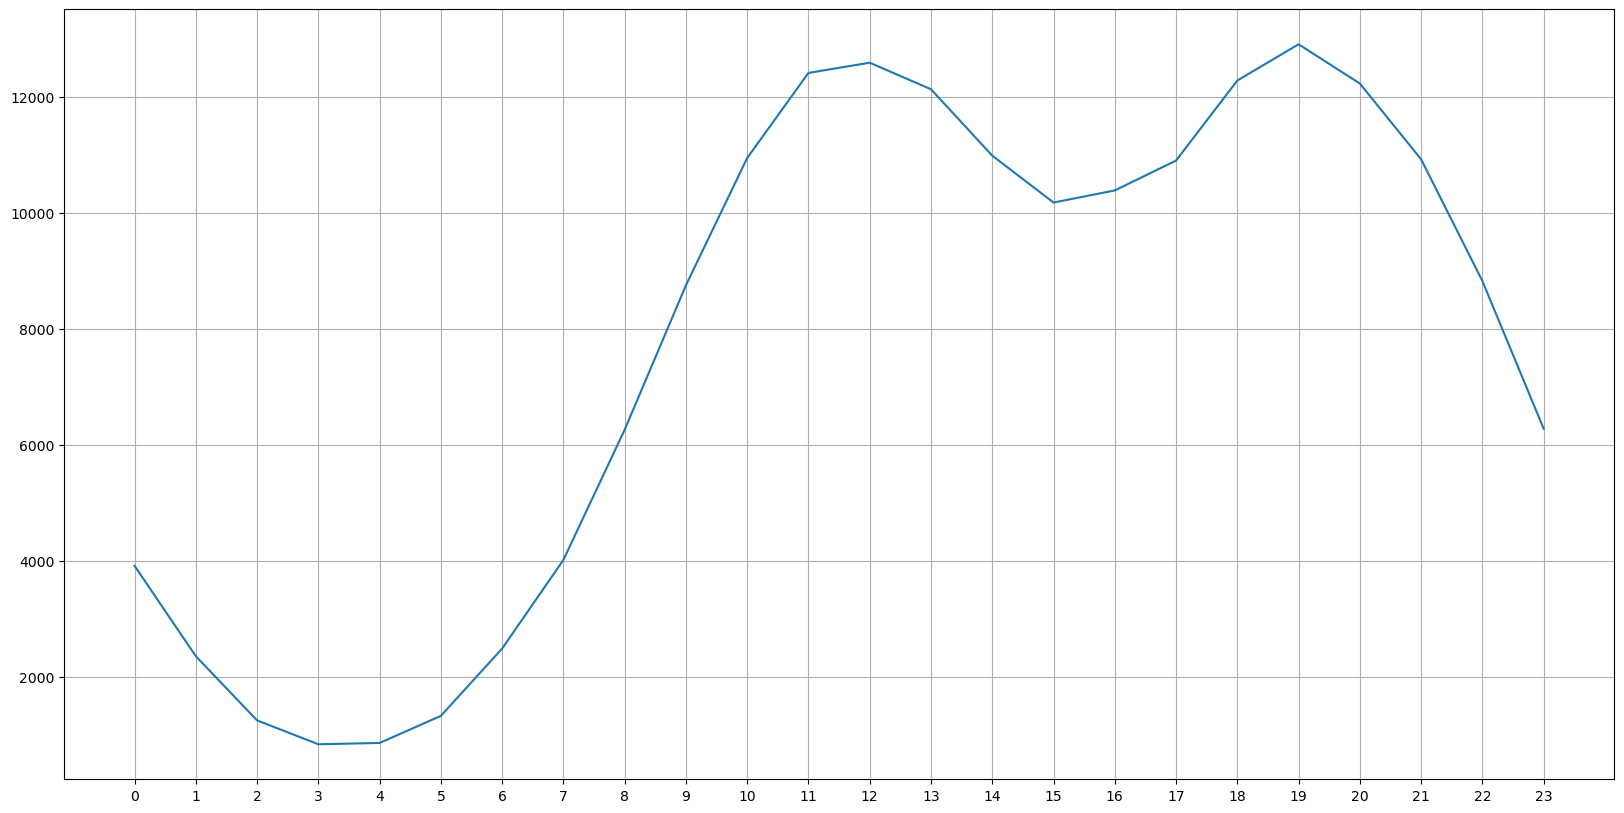

In [82]:
plt.figure(figsize=(20,10))
plt.grid()
plt.plot(order_hour.index,order_hour.values)
plt.xticks(order_hour.index)
plt.show()